In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df_raw = pd.read_csv('data/raw_data.csv')
df_raw.head(5)

,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100),previous_year_marks_pct
0,S1000,84,30,36,7,3,72,62.02
1,S1001,91,24,38,6,3,56,52.11
2,S1002,73,29,26,7,3,56,45.42
3,S1003,80,36,35,7,3,74,68.90
4,S1004,84,31,37,8,3,66,59.63


In [53]:
df = df_raw.copy(deep=True)

In [54]:
df.shape

(2000, 8)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Student_ID                     2000 non-null   object 
 1   Attendance (%)                 2000 non-null   int64  
 2   Internal Test 1 (out of 40)    2000 non-null   int64  
 3   Internal Test 2 (out of 40)    2000 non-null   int64  
 4   Assignment Score (out of 10)   2000 non-null   int64  
 5   Daily Study Hours              2000 non-null   int64  
 6   Final Exam Marks (out of 100)  2000 non-null   int64  
 7   previous_year_marks_pct        2000 non-null   float64
dtypes: float64(1), int64(6), object(1)
memory usage: 125.1+ KB


In [56]:
# Rename columns
df = df.rename(columns={
    'Student_ID': 'student_id',
    'Attendance (%)': 'attendance_pct',
    'Internal Test 1 (out of 40)': 'internal_test_1_pct',
    'Internal Test 2 (out of 40)': 'internal_test_2_pct',
    'Assignment Score (out of 10)': 'assignment_score_pct',
    'Daily Study Hours': 'daily_study_hours',
    'Previous Year Marks (out of 100)': 'previous_year_marks_pct',
    'Final Exam Marks (out of 100)': 'final_marks_pct'
})

# Convert scores to percentages
df['attendance_pct'] = df['attendance_pct'].astype(float)

df['internal_test_1_pct'] = (df['internal_test_1_pct'] / 40) * 100
df['internal_test_2_pct'] = (df['internal_test_2_pct'] / 40) * 100
df['assignment_score_pct'] = (df['assignment_score_pct'] / 10) * 100

df['daily_study_hours'] = df['daily_study_hours'].astype(float)
df['previous_year_marks_pct'] = df['previous_year_marks_pct'].astype(float)
df['final_marks_pct'] = df['final_marks_pct'].astype(float)

# Check
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               2000 non-null   object 
 1   attendance_pct           2000 non-null   float64
 2   internal_test_1_pct      2000 non-null   float64
 3   internal_test_2_pct      2000 non-null   float64
 4   assignment_score_pct     2000 non-null   float64
 5   daily_study_hours        2000 non-null   float64
 6   final_marks_pct          2000 non-null   float64
 7   previous_year_marks_pct  2000 non-null   float64
dtypes: float64(7), object(1)
memory usage: 125.1+ KB
None
  student_id  attendance_pct  internal_test_1_pct  internal_test_2_pct  \
0      S1000            84.0                 75.0                 90.0   
1      S1001            91.0                 60.0                 95.0   
2      S1002            73.0                 72.5                 65.0   

In [57]:
df.describe()

,attendance_pct,internal_test_1_pct,internal_test_2_pct,assignment_score_pct,daily_study_hours,final_marks_pct,previous_year_marks_pct
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,84.891500,80.288750,81.161250,75.070000,2.823500,64.855000,60.581320
std,7.758855,11.408761,11.307069,10.210153,0.608714,11.341265,13.880605
min,52.000000,45.000000,40.000000,40.000000,1.000000,25.000000,40.000000
25%,80.000000,72.500000,72.500000,70.000000,2.000000,58.000000,49.590000
50%,85.000000,80.000000,82.500000,80.000000,3.000000,65.000000,60.320000
75%,90.000000,87.500000,90.000000,80.000000,3.000000,73.000000,70.570000
max,100.000000,100.000000,100.000000,100.000000,5.000000,100.000000,95.000000


In [58]:
df.duplicated().sum()

np.int64(0)

In [59]:
df.corr(numeric_only=True)

,attendance_pct,internal_test_1_pct,internal_test_2_pct,assignment_score_pct,daily_study_hours,final_marks_pct,previous_year_marks_pct
attendance_pct,1.000000,0.505033,0.494560,0.432373,0.298767,0.725644,0.708651
internal_test_1_pct,0.505033,1.000000,0.263400,0.568047,0.213539,0.689227,0.719858
internal_test_2_pct,0.494560,0.263400,1.000000,0.541970,0.225670,0.691049,0.711097
assignment_score_pct,0.432373,0.568047,0.541970,1.000000,0.169005,0.669400,0.723813
daily_study_hours,0.298767,0.213539,0.225670,0.169005,1.000000,0.412877,0.484143
final_marks_pct,0.725644,0.689227,0.691049,0.669400,0.412877,1.000000,0.876055
previous_year_marks_pct,0.708651,0.719858,0.711097,0.723813,0.484143,0.876055,1.000000


## Univariant Analysis

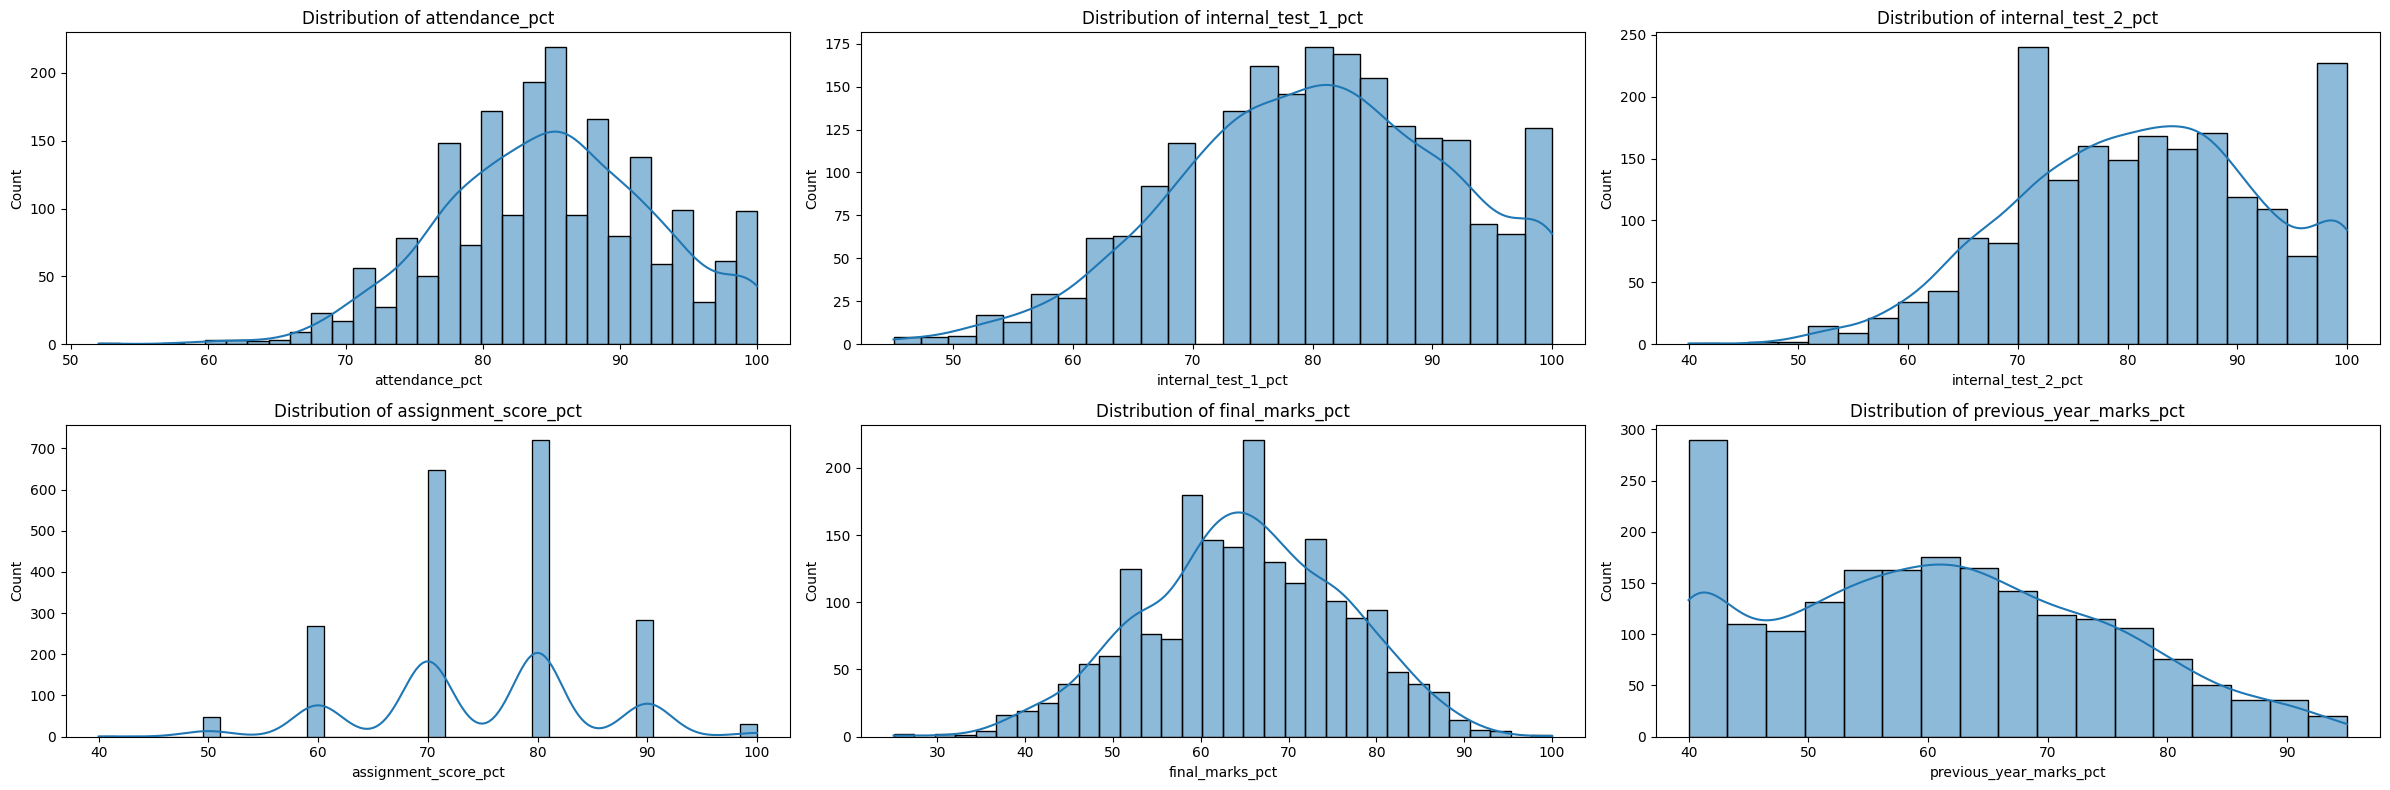

In [60]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 8))
axes = axes.flatten()
temp_df = df.drop(columns=['daily_study_hours', 'student_id'])
for i, column in enumerate(temp_df.columns):
    sns.histplot(df[column], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {column}')
plt.tight_layout()
plt.show()

In [61]:
df['daily_study_hours'].value_counts()

daily_study_hours
3.0    1248
2.0     533
4.0     202
1.0      14
5.0       3
Name: count, dtype: int64

## Feature engineering

In [62]:
df.drop(columns=['student_id'], inplace = True)
df.sample()

,attendance_pct,internal_test_1_pct,internal_test_2_pct,assignment_score_pct,daily_study_hours,final_marks_pct,previous_year_marks_pct
403,84.0,80.0,80.0,80.0,3.0,67.0,60.08


In [63]:
# Average of internal tests
df["internal_avg_pct"] = (
    df["internal_test_1_pct"] +
    df["internal_test_2_pct"]
) / 2

In [64]:
df.sample(2)

,attendance_pct,internal_test_1_pct,internal_test_2_pct,assignment_score_pct,daily_study_hours,final_marks_pct,previous_year_marks_pct,internal_avg_pct
1071,88.0,60.0,92.5,60.0,2.0,56.0,43.40,76.25
1119,81.0,87.5,70.0,80.0,2.0,58.0,49.54,78.75


In [65]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [66]:
X = df.drop(columns=[
    "final_marks_pct", "internal_test_1_pct", "internal_test_2_pct"
])

y = df["final_marks_pct"]

In [67]:
X.columns

Index(['attendance_pct', 'assignment_score_pct', 'daily_study_hours',
       'previous_year_marks_pct', 'internal_avg_pct'],
      dtype='object')

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 1600
Testing samples : 400


In [69]:
models = {

    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [70]:
results = []
for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2,
    })


In [71]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print("\nModel Performance:")
print(results_df.to_string(index=False))


Model Performance:
            Model      MAE     RMSE  R2 Score
Linear Regression 3.660859 4.607189  0.830516
Gradient Boosting 3.723848 4.733920  0.821064
    Random Forest 3.964136 4.999049  0.800460


In [72]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer
import matplotlib.pyplot as plt


# =========================================================
# 8. 5-Fold Cross Validation
# =========================================================

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R2": scores["test_R2"].mean(),
        "R2 Std": scores["test_R2"].std()
    })


cv_df = pd.DataFrame(cv_results)

cv_df = cv_df.sort_values(
    by="CV R2",
    ascending=False
)

print("\n5-Fold Cross Validation:")
print(cv_df.to_string(index=False))


5-Fold Cross Validation:
            Model   CV MAE  CV RMSE    CV R2   R2 Std
Linear Regression 3.611545 4.576502 0.836477 0.008233
Gradient Boosting 3.794916 4.796341 0.820520 0.005209
    Random Forest 4.014795 5.070441 0.799356 0.008660


In [73]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="r2",
    n_repeats=10,
    random_state=42
)

importance = pd.Series(
    result.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

print(importance)

internal_avg_pct           0.242104
previous_year_marks_pct    0.224411
attendance_pct             0.082834
assignment_score_pct       0.022044
daily_study_hours          0.006380
dtype: float64


In [74]:
best_model = models["Linear Regression"]

best_model.fit(X_train, y_train)

student_1 = {
    "attendance_pct": 90,
    "internal_test_1_pct": 78,
    "internal_test_2_pct": 82,
    "assignment_score_pct": 88,
    "daily_study_hours": 4,
    "previous_year_marks_pct": 87
    
}

student_2 = {
    "attendance_pct": 70,
    "internal_test_1_pct": 55,
    "internal_test_2_pct": 40,
    "assignment_score_pct": 65,
    "daily_study_hours": 2,
    "previous_year_marks_pct": 45
}

student_3 = {
    "attendance_pct": 98,
    "internal_test_1_pct": 92,
    "internal_test_2_pct": 95,
    "assignment_score_pct": 94,
    "daily_study_hours": 7,
    "previous_year_marks_pct": 92
}

def predict_student(student):

    student_df = pd.DataFrame([student])

    # Same feature engineering used during training
    student_df["internal_avg_pct"] = (
        student_df["internal_test_1_pct"] +
        student_df["internal_test_2_pct"]
    ) / 2

    student_df.drop(columns=['internal_test_1_pct','internal_test_2_pct'], inplace = True)
    # Prediction
    prediction = best_model.predict(student_df)[0]

    # Keep prediction within valid marks range
    prediction = np.clip(prediction, 0, 100)

    return prediction


students = [
    ("Student 1", student_1),
    ("Student 2", student_2),
    ("Student 3", student_3)
]

for name, student in students:

    prediction = predict_student(student)

    print(
        f"{name}: Predicted Final Marks = "
        f"{prediction:.2f}%"
    )

Student 1: Predicted Final Marks = 72.69%
Student 2: Predicted Final Marks = 33.37%
Student 3: Predicted Final Marks = 93.06%
